# 03 12.3 F NL IR Cleaning Walkthrough

This notebook walks through the cleaning of ENTSO-E `12.3 F NL IR` step by step:

- starting from the raw paginated zip/XML files in `data/00_Raw/ENTSOE/12_3_F_NL_IR`
- transforming the XML payload into a readable native offer table
- diagnosing pagination, full-period rows, ambiguous duplicates, and delivery coverage
- building cleaned offer-stack features
- aggregating offers into daily direction summaries
- expanding those summaries to hourly outputs for a consistent time axis

The key structural finding here is different from both `17.1 B&C` and `12.3 E A61`:

- this dataset contains **many offer rows per delivery day**
- the raw API export is paginated in 100-row chunks
- each offer row is still a **one-point full-period daily record**

So the cleaning keeps the native offer rows intact and then builds comparable aggregated totals on top.


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
import zipfile
from pathlib import Path

import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


def load_cleaning_module(repo_root: Path):
    module_path = repo_root / "scripts" / "Data" / "01_cleaning" / "procured_balancing_capacity_pipeline.py"
    spec = importlib.util.spec_from_file_location("procured_balancing_capacity_cleaning_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


REPO_ROOT = find_repo_root()
cleaning = load_cleaning_module(REPO_ROOT)


In [2]:
RAW_DIR = REPO_ROOT / "data" / "00_Raw" / "ENTSOE" / "12_3_F_NL_IR"
OUTPUT_DIR = REPO_ROOT / "data" / "01_cleaned" / "Balancing" / "IR Capacity" / "12_3_f_nl_ir"
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"

config_df = pd.DataFrame(
    [
        {"setting": "Raw input directory", "value": str(RAW_DIR)},
        {"setting": "Cleaned output directory", "value": str(OUTPUT_DIR)},
        {"setting": "Market", "value": cleaning.MARKET},
        {"setting": "Reporting timezone", "value": cleaning.MARKET_TIMEZONE},
        {"setting": "Known-at rule", "value": cleaning.KNOWN_AT_RULE},
    ]
)
display(config_df)


,setting,value
0,Raw input directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\12_3_F_NL_IR
1,Cleaned output directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\IR Capacity\12_3_f_nl_ir
2,Market,NL
3,Reporting timezone,Europe/Amsterdam
4,Known-at rule,created_datetime_utc_from_export_only_not_forecast_safe


## 1. Raw Zip Inventory

Start with the archive inventory. Because this export is paginated, the zip-level view is part of the diagnosis rather than just a file check.


,archive,offset,size_kb,xml_member_count
0,12_3_f_nl_ir_2025_offset_0000.zip,0,2.3,1
1,12_3_f_nl_ir_2025_offset_0100.zip,100,2.3,1
2,12_3_f_nl_ir_2025_offset_0200.zip,200,2.3,1
3,12_3_f_nl_ir_2025_offset_0300.zip,300,2.3,1
4,12_3_f_nl_ir_2025_offset_0400.zip,400,2.3,1
5,12_3_f_nl_ir_2025_offset_0500.zip,500,2.3,1
6,12_3_f_nl_ir_2025_offset_0600.zip,600,2.3,1
7,12_3_f_nl_ir_2025_offset_0700.zip,700,2.3,1
8,12_3_f_nl_ir_2025_offset_0800.zip,800,2.4,1
9,12_3_f_nl_ir_2025_offset_0900.zip,900,2.4,1


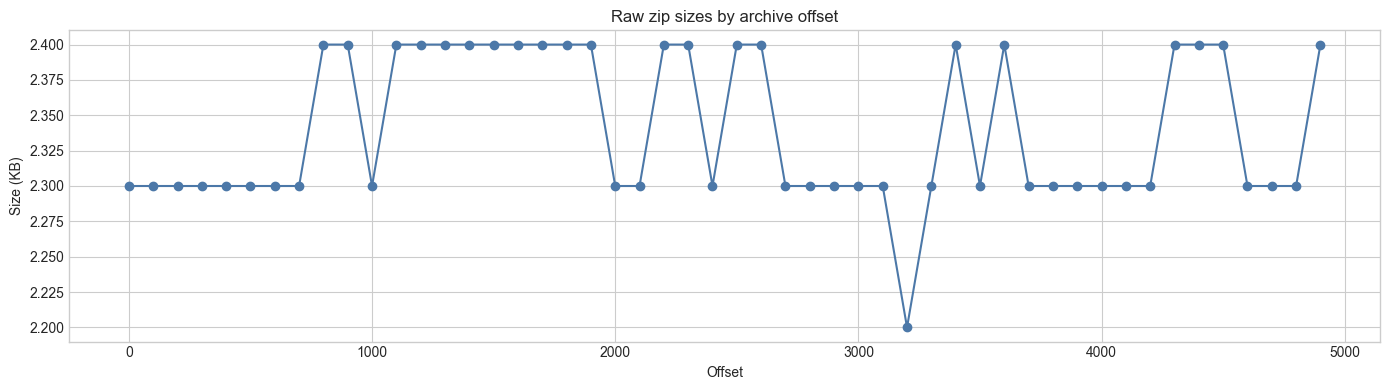

In [3]:
inventory_rows = []
for archive_path in sorted(RAW_DIR.glob("*.zip")):
    with zipfile.ZipFile(archive_path) as zf:
        xml_members = [name for name in zf.namelist() if name.lower().endswith(".xml")]
    inventory_rows.append(
        {
            "archive": archive_path.name,
            "offset": cleaning.parse_archive_offset(archive_path.name),
            "size_kb": round(archive_path.stat().st_size / 1024, 1),
            "xml_member_count": len(xml_members),
        }
    )

inventory_df = pd.DataFrame(inventory_rows).sort_values("offset").reset_index(drop=True)
display(inventory_df.head(20))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(inventory_df["offset"], inventory_df["size_kb"], marker="o", color="#4C78A8")
ax.set_title("Raw zip sizes by archive offset")
ax.set_xlabel("Offset")
ax.set_ylabel("Size (KB)")
plt.tight_layout()
plt.show()


## 2. Inspect One Raw XML Member

Read one XML member directly to make the document structure visible before flattening it into tables.


In [4]:
sample_archive = sorted(RAW_DIR.glob("*.zip"))[0]
with zipfile.ZipFile(sample_archive) as zf:
    sample_member = sorted(name for name in zf.namelist() if name.lower().endswith(".xml"))[0]
    sample_xml_text = zf.read(sample_member).decode("utf-8", errors="replace")

print("Archive:", sample_archive.name)
print("Member:", sample_member)
print()
print("\n".join(sample_xml_text.splitlines()[:50]))


Archive: 12_3_f_nl_ir_2025_offset_0000.zip
Member: 001-PROCURED_BALANCING_CAPACITY_R3_202501062300-202501072300.xml

<?xml version="1.0" encoding="utf-8"?>
  <Balancing_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:balancingdocument:4:1">
    <mRID>1886175135d8481c841a7050fff35449</mRID>
    <revisionNumber>1</revisionNumber>
    <type>A15</type>
    <process.processType>A47</process.processType>
    <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
    <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
    <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
    <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
    <createdDateTime>2026-03-25T16:10:42Z</createdDateTime>
    <area_Domain.mRID codingScheme="A01">10YNL----------L</area_Domain.mRID>
    <period.timeInterval>
      <start>2025-01-06T23:00

## 3. Parse the Raw Files Into a Readable Offer Table

The first cleaned table keeps one row per native offer row from the XML.


In [5]:
offers_raw, archive_summary_df, parse_errors_df = cleaning.parse_archives(RAW_DIR)

print(f"Offer rows parsed: {len(offers_raw):,}")
print(f"Archive summaries: {len(archive_summary_df):,}")
print(f"Parse errors: {len(parse_errors_df):,}")

display(archive_summary_df.head(20))
if not parse_errors_df.empty:
    display(parse_errors_df)


Offer rows parsed: 5,000
Archive summaries: 50
Parse errors: 0


,source_archive,source_archive_offset,size_kb,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,document_period_start_utc,document_period_end_utc,offer_rows,unique_delivery_periods,flow_direction_distribution,point_count_distribution
0,12_3_f_nl_ir_2025_offset_0000.zip,0,2.3,2026-03-25T16:10:42+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-06T23:00:00+00:00,2025-01-07T23:00:00+00:00,100,1,"{""A01"": 25, ""A02"": 75}","{""1"": 100}"
1,12_3_f_nl_ir_2025_offset_0100.zip,100,2.3,2026-03-25T16:10:44+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-06T23:00:00+00:00,2025-01-09T23:00:00+00:00,100,3,"{""A01"": 36, ""A02"": 64}","{""1"": 100}"
2,12_3_f_nl_ir_2025_offset_0200.zip,200,2.3,2026-03-25T16:10:45+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-08T23:00:00+00:00,2025-01-10T23:00:00+00:00,100,2,"{""A01"": 33, ""A02"": 67}","{""1"": 100}"
3,12_3_f_nl_ir_2025_offset_0300.zip,300,2.3,2026-03-25T16:10:45+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-09T23:00:00+00:00,2025-01-11T23:00:00+00:00,100,2,"{""A01"": 36, ""A02"": 64}","{""1"": 100}"
4,12_3_f_nl_ir_2025_offset_0400.zip,400,2.3,2026-03-25T16:10:46+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-10T23:00:00+00:00,2025-01-12T23:00:00+00:00,100,2,"{""A01"": 43, ""A02"": 57}","{""1"": 100}"
5,12_3_f_nl_ir_2025_offset_0500.zip,500,2.3,2026-03-25T16:10:46+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-11T23:00:00+00:00,2025-01-13T23:00:00+00:00,100,2,"{""A01"": 41, ""A02"": 59}","{""1"": 100}"
6,12_3_f_nl_ir_2025_offset_0600.zip,600,2.3,2026-03-25T16:10:47+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-12T23:00:00+00:00,2025-01-14T23:00:00+00:00,100,2,"{""A01"": 30, ""A02"": 70}","{""1"": 100}"
7,12_3_f_nl_ir_2025_offset_0700.zip,700,2.3,2026-03-25T16:10:49+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-13T23:00:00+00:00,2025-01-15T23:00:00+00:00,100,2,"{""A01"": 29, ""A02"": 71}","{""1"": 100}"
8,12_3_f_nl_ir_2025_offset_0800.zip,800,2.4,2026-03-25T16:10:49+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-14T23:00:00+00:00,2025-01-17T23:00:00+00:00,100,3,"{""A01"": 79, ""A02"": 21}","{""1"": 100}"
9,12_3_f_nl_ir_2025_offset_0900.zip,900,2.4,2026-03-25T16:10:50+00:00,A15,Acquiring_system_operator_reserve_schedule,A47,mFRR,2025-01-17T23:00:00+00:00,2025-01-20T23:00:00+00:00,100,3,"{""A01"": 79, ""A02"": 21}","{""1"": 100}"


In [6]:
readable_offers = (
    offers_raw[
        [
            "source_archive",
            "source_archive_offset",
            "timestamp_utc",
            "interval_end_utc",
            "flow_direction_label",
            "quantity_maw",
            "procurement_price_eur_per_maw",
            "interval_interpretation",
            "timeseries_mrid",
        ]
    ]
    .sort_values(["timestamp_utc", "flow_direction_label", "procurement_price_eur_per_maw", "quantity_maw"])
    .reset_index(drop=True)
)
display(readable_offers.head(20))


,source_archive,source_archive_offset,timestamp_utc,interval_end_utc,flow_direction_label,quantity_maw,procurement_price_eur_per_maw,interval_interpretation,timeseries_mrid
0,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,4,0.38,single_point_full_period,11
1,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,10,0.38,single_point_full_period,9
2,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,2
3,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,14
4,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,27
5,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,44
6,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,54
7,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,77
8,12_3_f_nl_ir_2025_offset_0000.zip,0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,99
9,12_3_f_nl_ir_2025_offset_0100.zip,100,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,Down,1,0.40,single_point_full_period,9


## 4. Diagnose Structure, Pagination, and Identity

The key structural questions are:

- how many delivery periods appear
- how many offers land in each delivery period
- whether rows are full-period records
- whether `timeseries mRID` is a stable identifier across pages


In [7]:
offers_long = cleaning.build_offer_stack(offers_raw)
offers_summary_df = cleaning.summarize_offers(offers_long)
ambiguous_duplicates_df = cleaning.build_ambiguous_duplicate_content_summary(offers_long)
mrid_reuse_df = cleaning.build_timeseries_mrid_reuse_summary(offers_long)

overview_df = pd.DataFrame(
    [
        {"metric": "Offer rows", "value": len(offers_long)},
        {"metric": "Unique delivery periods", "value": offers_long[["timestamp_utc", "interval_end_utc"]].drop_duplicates().shape[0]},
        {"metric": "Min timestamp UTC", "value": offers_long["timestamp_utc"].min()},
        {"metric": "Max interval end UTC", "value": offers_long["interval_end_utc"].max()},
        {"metric": "Unique archive offsets", "value": offers_long["source_archive_offset"].nunique()},
        {"metric": "Ambiguous duplicate-content groups", "value": len(ambiguous_duplicates_df)},
    ]
)
display(overview_df)
display(offers_summary_df)
display(mrid_reuse_df.head(20))


,metric,value
0,Offer rows,5000
1,Unique delivery periods,72
2,Min timestamp UTC,2025-01-06 23:00:00+00:00
3,Max interval end UTC,2025-03-19 23:00:00+00:00
4,Unique archive offsets,50
5,Ambiguous duplicate-content groups,589


,flow_direction_code,flow_direction_label,rows,unique_delivery_periods,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date,point_count_distribution,resolution_distribution,interval_interpretation_distribution
0,A01,Up,1920,72,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19,"{""1"": 1920}","{""PT15M"": 1920}","{""single_point_full_period"": 1920}"
1,A02,Down,3080,72,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19,"{""1"": 3080}","{""PT15M"": 3080}","{""single_point_full_period"": 3080}"


,timeseries_mrid,rows,source_archive_count,first_timestamp_utc,last_timestamp_utc
0,1,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
1,10,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
2,100,50,50,2025-01-06 23:00:00+00:00,2025-03-18 23:00:00+00:00
3,11,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
4,12,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
5,13,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
6,14,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
7,15,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
8,16,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00
9,17,50,50,2025-01-06 23:00:00+00:00,2025-03-16 23:00:00+00:00


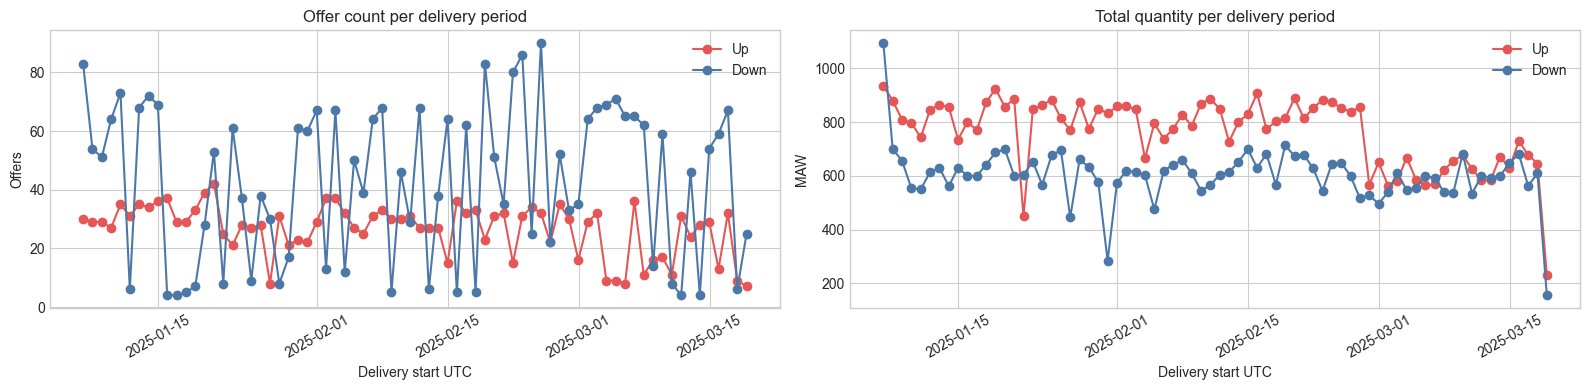

In [8]:
offers_per_period = (
    offers_long.groupby(["timestamp_utc", "interval_end_utc", "flow_direction_label"], as_index=False)
    .agg(offers=("native_offer_id", "size"), total_quantity_maw=("quantity_maw", "sum"))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = offers_per_period[offers_per_period["flow_direction_label"] == label]
    axes[0].plot(subset["timestamp_utc"], subset["offers"], marker="o", label=label, color=color)
    axes[1].plot(subset["timestamp_utc"], subset["total_quantity_maw"], marker="o", label=label, color=color)

axes[0].set_title("Offer count per delivery period")
axes[0].set_ylabel("Offers")
axes[0].set_xlabel("Delivery start UTC")
axes[0].legend()

axes[1].set_title("Total quantity per delivery period")
axes[1].set_ylabel("MAW")
axes[1].set_xlabel("Delivery start UTC")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [9]:
display(ambiguous_duplicates_df.head(30))

code_tables_df = pd.concat(
    [
        pd.DataFrame(cleaning.DOCUMENT_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="document_type"),
        pd.DataFrame(cleaning.PROCESS_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="process_type"),
        pd.DataFrame(cleaning.BUSINESS_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="business_type"),
        pd.DataFrame(cleaning.CONTRACT_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="contract_type"),
        pd.DataFrame(cleaning.RESERVE_SOURCE_LABELS.items(), columns=["code", "label"]).assign(code_family="reserve_source"),
        pd.DataFrame(cleaning.FLOW_DIRECTION_LABELS.items(), columns=["code", "label"]).assign(code_family="flow_direction"),
    ],
    ignore_index=True,
)
display(code_tables_df)


,timestamp_utc,interval_end_utc,flow_direction_code,flow_direction_label,quantity_maw,procurement_price_eur_per_maw,ambiguous_offer_rows,source_archive_count
0,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A01,Up,150,6.57,2,1
1,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,1,0.40,8,2
2,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,1,0.41,16,2
3,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,1,0.42,16,2
4,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,1,0.43,16,2
5,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,1,0.44,4,2
6,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,A02,Down,150,1.75,5,2
7,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,A01,Up,150,6.06,2,1
8,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,A02,Down,1,0.40,7,1
9,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,A02,Down,1,0.41,12,1


,code,label,code_family
0,A15,Acquiring_system_operator_reserve_schedule,document_type
1,A47,mFRR,process_type
2,B95,Procured_capacity,business_type
3,A01,Daily,contract_type
4,A02,Weekly,contract_type
5,A03,Monthly,contract_type
6,A04,Yearly,contract_type
7,A06,Long_term_contract,contract_type
8,A13,Hourly,contract_type
9,A01,Standard,reserve_source


## 5. Cleaning Step 1: Build the Offer Stack

The cleaned native table keeps every offer row and adds stack features:

- offer rank by ascending procurement price
- cumulative quantity within delivery period and direction
- quantity shares within the day-direction stack


In [10]:
display(
    offers_long[
        [
            "timestamp_utc",
            "flow_direction_label",
            "offer_rank_price_asc",
            "quantity_maw",
            "procurement_price_eur_per_maw",
            "cumulative_quantity_maw",
            "cumulative_quantity_share",
        ]
    ].head(30)
)


,timestamp_utc,flow_direction_label,offer_rank_price_asc,quantity_maw,procurement_price_eur_per_maw,cumulative_quantity_maw,cumulative_quantity_share
0,2025-01-06 23:00:00+00:00,Up,1,70,2.47,70,0.074866
1,2025-01-06 23:00:00+00:00,Up,2,15,2.75,85,0.090909
2,2025-01-06 23:00:00+00:00,Up,3,130,3.00,215,0.229947
3,2025-01-06 23:00:00+00:00,Up,4,40,3.00,255,0.272727
4,2025-01-06 23:00:00+00:00,Up,5,1,3.04,256,0.273797
5,2025-01-06 23:00:00+00:00,Up,6,20,3.06,276,0.295187
6,2025-01-06 23:00:00+00:00,Up,7,1,3.06,277,0.296257
7,2025-01-06 23:00:00+00:00,Up,8,1,3.08,278,0.297326
8,2025-01-06 23:00:00+00:00,Up,9,1,3.10,279,0.298396
9,2025-01-06 23:00:00+00:00,Up,10,1,3.13,280,0.299465


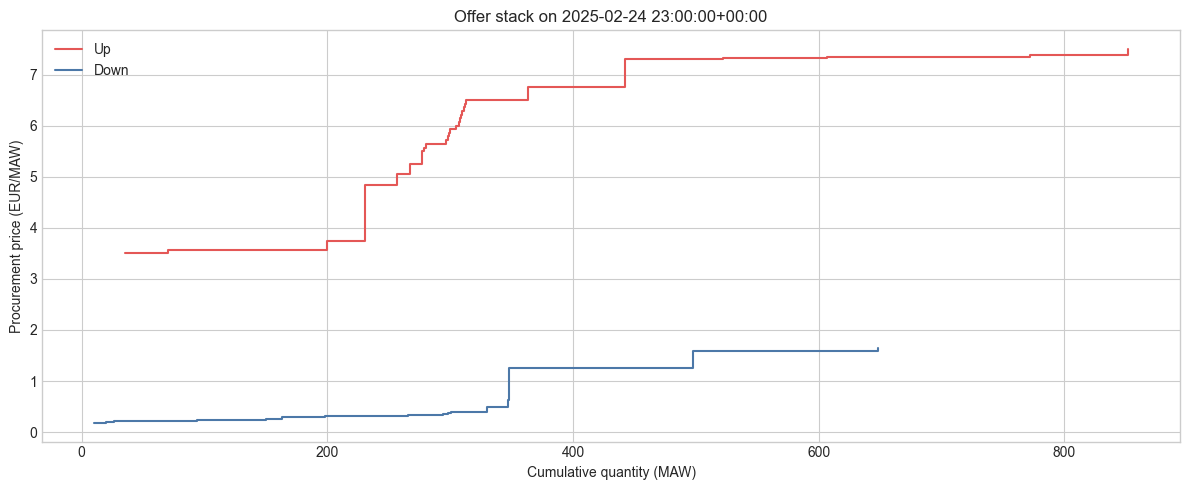

In [11]:
sample_period = (
    offers_long.groupby(["timestamp_utc", "flow_direction_label"], as_index=False)
    .agg(offers=("native_offer_id", "size"))
    .sort_values("offers", ascending=False)
    .iloc[0]["timestamp_utc"]
)

sample_stack = offers_long[offers_long["timestamp_utc"] == sample_period].copy()

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = sample_stack[sample_stack["flow_direction_label"] == label].sort_values("offer_rank_price_asc")
    ax.step(subset["cumulative_quantity_maw"], subset["procurement_price_eur_per_maw"], where="post", label=label, color=color)
ax.set_title(f"Offer stack on {sample_period}")
ax.set_xlabel("Cumulative quantity (MAW)")
ax.set_ylabel("Procurement price (EUR/MAW)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Cleaning Step 2: Aggregate to Daily Direction Summaries

The native offers are then aggregated into comparable day-direction totals:

- offer count
- total quantity
- quantity-weighted procurement price
- price distribution summaries


In [12]:
daily_long = cleaning.build_daily_direction_summary(offers_long)
daily_wide = cleaning.build_daily_direction_wide(daily_long)
daily_summary_df = cleaning.summarize_daily(daily_long)

print(f"Daily summary rows: {len(daily_long):,}")
display(daily_summary_df)
display(daily_long.head(20))
display(daily_wide.head(12))


Daily summary rows: 144


,flow_direction_code,flow_direction_label,rows,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date,total_offers,total_quantity_maw
0,A01,Up,72,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19,1920,54889.0
1,A02,Down,72,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19,3080,43451.0


,family,market,timestamp_utc,interval_end_utc,effective_interval_minutes,offer_count,total_quantity_maw,quantity_weighted_price_eur_per_maw,price_mean_eur_per_maw,price_median_eur_per_maw,price_min_eur_per_maw,price_max_eur_per_maw,unique_price_levels,max_offer_quantity_maw,source_archive_count,source_offer_rows,flow_direction_code,flow_direction_label,contract_type_code,contract_type_label,reserve_source_code,reserve_source_label,business_type_code,business_type_label,market_product_type_code,currency_unit,quantity_unit,price_measure_unit,target_delivery_local_date,target_hour_local,target_minute_local,known_at_utc,known_at_rule
0,12_3_f_nl_ir,NL,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,1440,30,935,19.566684,95.478333,3.360,2.47,2500.00,25,150,2,30,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-07,0,0,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe
1,12_3_f_nl_ir,NL,2025-01-06 23:00:00+00:00,2025-01-07 23:00:00+00:00,1440,83,1094,1.513464,1.047952,0.420,0.38,20.00,17,150,2,83,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-07,0,0,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe
2,12_3_f_nl_ir,NL,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,1440,29,880,4.825830,4.027586,3.560,2.75,6.06,26,150,1,29,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-08,0,0,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe
3,12_3_f_nl_ir,NL,2025-01-07 23:00:00+00:00,2025-01-08 23:00:00+00:00,1440,54,700,0.461457,0.422407,0.420,0.40,0.47,6,150,1,54,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-08,0,0,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe
4,12_3_f_nl_ir,NL,2025-01-08 23:00:00+00:00,2025-01-09 23:00:00+00:00,1440,29,809,4.923498,4.753793,4.660,3.06,6.48,24,150,2,29,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-09,0,0,2026-03-25 16:10:45+00:00,created_datetime_utc_from_export_only_not_forecast_safe
5,12_3_f_nl_ir,NL,2025-01-08 23:00:00+00:00,2025-01-09 23:00:00+00:00,1440,51,656,0.368232,0.350784,0.350,0.33,0.37,5,150,2,51,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-09,0,0,2026-03-25 16:10:45+00:00,created_datetime_utc_from_export_only_not_forecast_safe
6,12_3_f_nl_ir,NL,2025-01-09 23:00:00+00:00,2025-01-10 23:00:00+00:00,1440,27,797,5.118294,4.744074,4.570,3.50,6.25,23,150,2,27,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-10,0,0,2026-03-25 16:10:45+00:00,created_datetime_utc_from_export_only_not_forecast_safe
7,12_3_f_nl_ir,NL,2025-01-09 23:00:00+00:00,2025-01-10 23:00:00+00:00,1440,64,554,0.773574,0.346250,0.290,0.25,1.11,19,150,2,64,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-10,0,0,2026-03-25 16:10:45+00:00,created_datetime_utc_from_export_only_not_forecast_safe
8,12_3_f_nl_ir,NL,2025-01-10 23:00:00+00:00,2025-01-11 23:00:00+00:00,1440,35,743,4.368412,3.731429,3.480,2.47,5.30,31,150,2,35,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-11,0,0,2026-03-25 16:10:46+00:00,created_datetime_utc_from_export_only_not_forecast_safe
9,12_3_f_nl_ir,NL,2025-01-10 23:00:00+00:00,2025-01-11 23:00:00+00:00,1440,73,550,0.921291,0.726986,0.730,0.35,1.11,27,150,2,73,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2025-01-11,0,0,2026-03-25 16:10:46+00:00,created_datetime_utc_from_export_only_not_forecast_safe


,timestamp_utc,nl_down_offer_count,nl_down_quantity_weighted_price_eur_per_maw,nl_down_total_quantity_maw,nl_up_offer_count,nl_up_quantity_weighted_price_eur_per_maw,nl_up_total_quantity_maw
0,2025-01-06 23:00:00+00:00,83,1.513464,1094,30,19.566684,935
1,2025-01-07 23:00:00+00:00,54,0.461457,700,29,4.825830,880
2,2025-01-08 23:00:00+00:00,51,0.368232,656,29,4.923498,809
3,2025-01-09 23:00:00+00:00,64,0.773574,554,27,5.118294,797
4,2025-01-10 23:00:00+00:00,73,0.921291,550,35,4.368412,743
5,2025-01-11 23:00:00+00:00,6,0.529316,614,31,3.100532,846
6,2025-01-12 23:00:00+00:00,68,0.445730,630,35,4.597037,864
7,2025-01-13 23:00:00+00:00,72,0.818523,562,34,4.648797,856
8,2025-01-14 23:00:00+00:00,69,0.487746,630,36,7.341224,735
9,2025-01-15 23:00:00+00:00,4,0.280000,600,37,6.939476,801


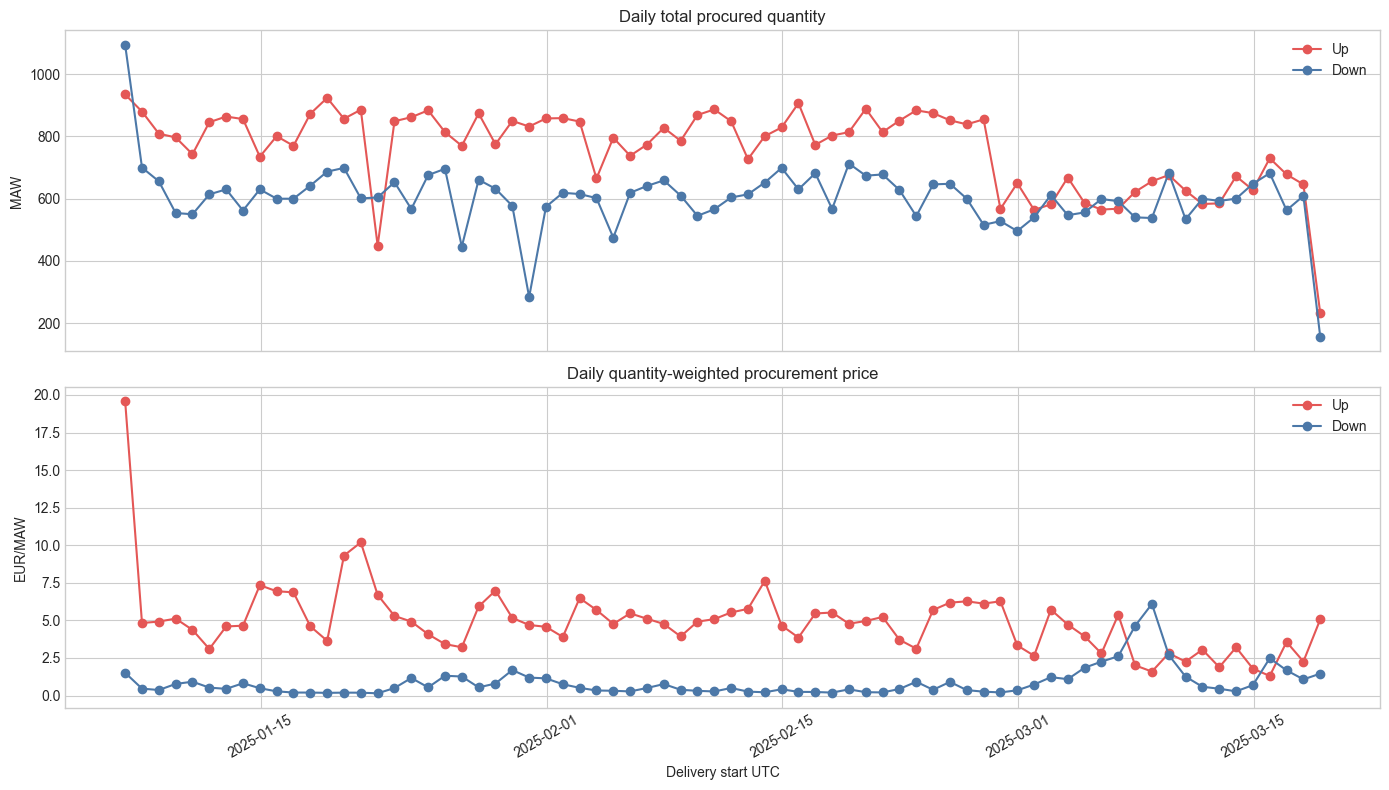

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = daily_long[daily_long["flow_direction_label"] == label]
    axes[0].plot(subset["timestamp_utc"], subset["total_quantity_maw"], marker="o", label=label, color=color)
    axes[1].plot(subset["timestamp_utc"], subset["quantity_weighted_price_eur_per_maw"], marker="o", label=label, color=color)

axes[0].set_title("Daily total procured quantity")
axes[0].set_ylabel("MAW")
axes[0].legend()

axes[1].set_title("Daily quantity-weighted procurement price")
axes[1].set_ylabel("EUR/MAW")
axes[1].set_xlabel("Delivery start UTC")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 7. Cleaning Step 3: Expand Aggregated Totals to Hourly

The raw offers are daily full-period records, so the hourly layer is an expansion of the aggregated daily totals over the covered UTC hours.


In [14]:
hourly_long = cleaning.build_hourly_direction_summary(daily_long)
hourly_wide = cleaning.build_hourly_direction_wide(hourly_long)
hourly_summary_df = cleaning.summarize_hourly(hourly_long)

print(f"Hourly summary rows: {len(hourly_long):,}")
display(hourly_summary_df)
display(hourly_long.head(20))
display(hourly_wide.head(12))


Hourly summary rows: 3,456


,flow_direction_code,flow_direction_label,rows,unique_hours,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,1728,1728,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19
1,A02,Down,1728,1728,2025-01-06T23:00:00+00:00,2025-03-19T23:00:00+00:00,2025-01-07,2025-03-19


,family,market,timestamp_utc,interval_end_utc,effective_interval_minutes,offer_count,total_quantity_maw,quantity_weighted_price_eur_per_maw,price_mean_eur_per_maw,price_median_eur_per_maw,price_min_eur_per_maw,price_max_eur_per_maw,unique_price_levels,max_offer_quantity_maw,source_archive_count,source_offer_rows,is_complete_hour,flow_direction_code,flow_direction_label,contract_type_code,contract_type_label,reserve_source_code,reserve_source_label,business_type_code,business_type_label,market_product_type_code,currency_unit,quantity_unit,price_measure_unit,known_at_utc,known_at_rule,target_delivery_local_date,target_hour_local,target_minute_local
0,12_3_f_nl_ir,NL,2025-01-06 23:00:00+00:00,2025-01-07 00:00:00+00:00,60,30,935,19.566684,95.478333,3.36,2.47,2500.0,25,150,2,30,True,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,0,0
1,12_3_f_nl_ir,NL,2025-01-06 23:00:00+00:00,2025-01-07 00:00:00+00:00,60,83,1094,1.513464,1.047952,0.42,0.38,20.0,17,150,2,83,True,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,0,0
2,12_3_f_nl_ir,NL,2025-01-07 00:00:00+00:00,2025-01-07 01:00:00+00:00,60,30,935,19.566684,95.478333,3.36,2.47,2500.0,25,150,2,30,True,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,1,0
3,12_3_f_nl_ir,NL,2025-01-07 00:00:00+00:00,2025-01-07 01:00:00+00:00,60,83,1094,1.513464,1.047952,0.42,0.38,20.0,17,150,2,83,True,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,1,0
4,12_3_f_nl_ir,NL,2025-01-07 01:00:00+00:00,2025-01-07 02:00:00+00:00,60,30,935,19.566684,95.478333,3.36,2.47,2500.0,25,150,2,30,True,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,2,0
5,12_3_f_nl_ir,NL,2025-01-07 01:00:00+00:00,2025-01-07 02:00:00+00:00,60,83,1094,1.513464,1.047952,0.42,0.38,20.0,17,150,2,83,True,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,2,0
6,12_3_f_nl_ir,NL,2025-01-07 02:00:00+00:00,2025-01-07 03:00:00+00:00,60,30,935,19.566684,95.478333,3.36,2.47,2500.0,25,150,2,30,True,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,3,0
7,12_3_f_nl_ir,NL,2025-01-07 02:00:00+00:00,2025-01-07 03:00:00+00:00,60,83,1094,1.513464,1.047952,0.42,0.38,20.0,17,150,2,83,True,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,3,0
8,12_3_f_nl_ir,NL,2025-01-07 03:00:00+00:00,2025-01-07 04:00:00+00:00,60,30,935,19.566684,95.478333,3.36,2.47,2500.0,25,150,2,30,True,A01,Up,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,4,0
9,12_3_f_nl_ir,NL,2025-01-07 03:00:00+00:00,2025-01-07 04:00:00+00:00,60,83,1094,1.513464,1.047952,0.42,0.38,20.0,17,150,2,83,True,A02,Down,A01,Daily,A04,Local,B95,Procured_capacity,A02,EUR,MAW,MAW,2026-03-25 16:10:44+00:00,created_datetime_utc_from_export_only_not_forecast_safe,2025-01-07,4,0


,timestamp_utc,nl_down_offer_count,nl_down_quantity_weighted_price_eur_per_maw,nl_down_total_quantity_maw,nl_up_offer_count,nl_up_quantity_weighted_price_eur_per_maw,nl_up_total_quantity_maw
0,2025-01-06 23:00:00+00:00,83,1.513464,1094,30,19.566684,935
1,2025-01-07 00:00:00+00:00,83,1.513464,1094,30,19.566684,935
2,2025-01-07 01:00:00+00:00,83,1.513464,1094,30,19.566684,935
3,2025-01-07 02:00:00+00:00,83,1.513464,1094,30,19.566684,935
4,2025-01-07 03:00:00+00:00,83,1.513464,1094,30,19.566684,935
5,2025-01-07 04:00:00+00:00,83,1.513464,1094,30,19.566684,935
6,2025-01-07 05:00:00+00:00,83,1.513464,1094,30,19.566684,935
7,2025-01-07 06:00:00+00:00,83,1.513464,1094,30,19.566684,935
8,2025-01-07 07:00:00+00:00,83,1.513464,1094,30,19.566684,935
9,2025-01-07 08:00:00+00:00,83,1.513464,1094,30,19.566684,935


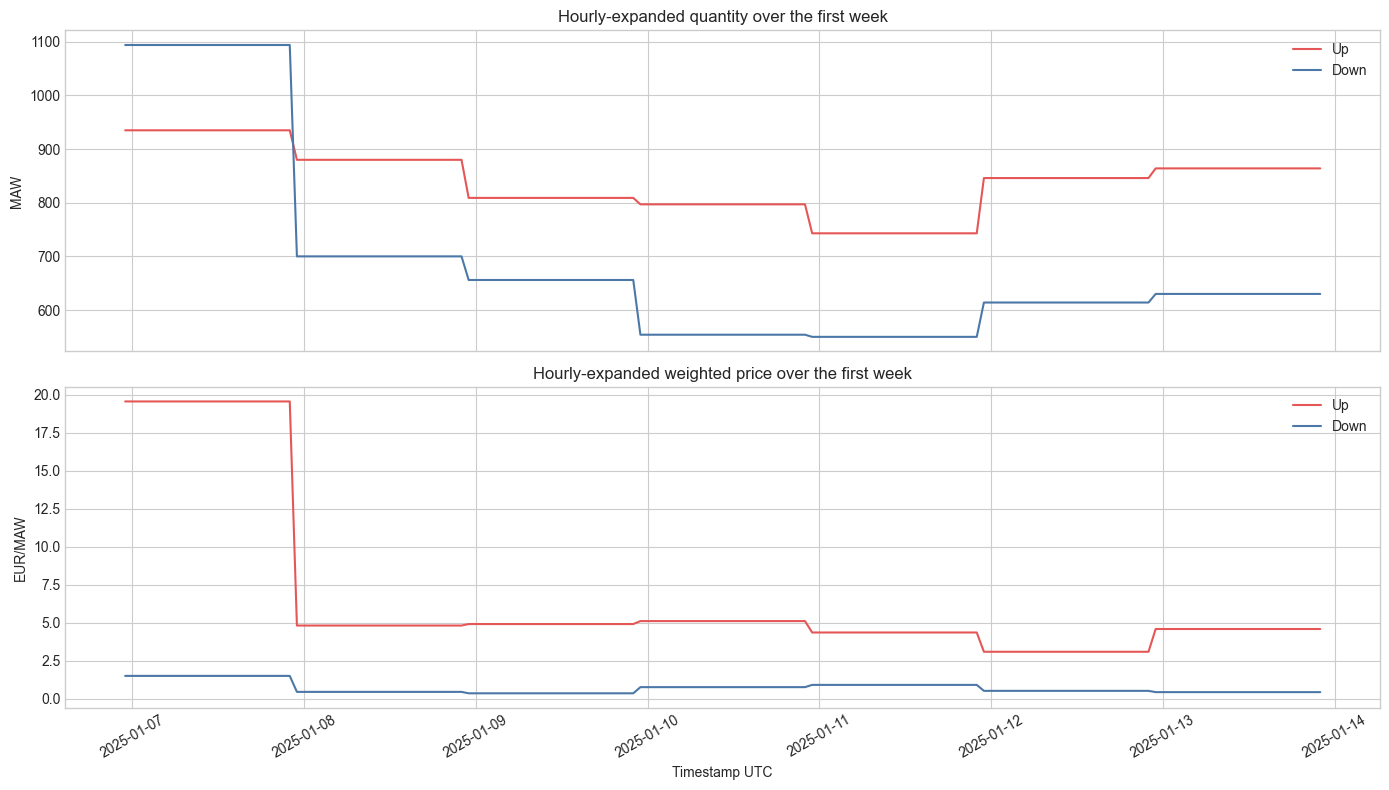

In [15]:
sample_hourly = hourly_long[
    (hourly_long["timestamp_utc"] >= hourly_long["timestamp_utc"].min())
    & (hourly_long["timestamp_utc"] < hourly_long["timestamp_utc"].min() + pd.Timedelta(days=7))
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = sample_hourly[sample_hourly["flow_direction_label"] == label]
    axes[0].plot(subset["timestamp_utc"], subset["total_quantity_maw"], label=label, color=color)
    axes[1].plot(subset["timestamp_utc"], subset["quantity_weighted_price_eur_per_maw"], label=label, color=color)

axes[0].set_title("Hourly-expanded quantity over the first week")
axes[0].set_ylabel("MAW")
axes[0].legend()

axes[1].set_title("Hourly-expanded weighted price over the first week")
axes[1].set_ylabel("EUR/MAW")
axes[1].set_xlabel("Timestamp UTC")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 8. Save the Cleaned Outputs

The final step writes the cleaned offer table, aggregated daily/hourly outputs, and diagnostics to the `IR Capacity` dataset folder.


In [16]:
metadata = cleaning.write_outputs(
    output_root=REPO_ROOT / "data" / "01_cleaned",
    offers_long=offers_long,
    daily_long=daily_long,
    daily_wide=daily_wide,
    hourly_long=hourly_long,
    hourly_wide=hourly_wide,
    archive_summary=archive_summary_df,
    parse_errors=parse_errors_df,
    offers_summary=offers_summary_df,
    daily_summary=daily_summary_df,
    hourly_summary=hourly_summary_df,
    ambiguous_duplicate_content=ambiguous_duplicates_df,
    timeseries_mrid_reuse=mrid_reuse_df,
)

display(pd.DataFrame({"artifact": list(metadata.keys()), "path_or_value": [str(v) for v in metadata.values()]}))


,artifact,path_or_value
0,dataset,12_3_f_nl_ir
1,market,NL
2,market_timezone_for_reporting,Europe/Amsterdam
3,raw_input_dir,data\00_Raw\ENTSOE\12_3_F_NL_IR
4,output_dir,data\01_cleaned\Balancing\IR Capacity\12_3_f_nl_ir
5,known_at_rule,created_datetime_utc_from_export_only_not_forecast_safe
6,notes,"['Raw data is paginated across many zip archives with one XML member each and up to 100 offer rows per archive.', 'Each native offer row is treated as a full-period daily contract when the file reports one point for the whole Period.', 'The native offer-level table is preserved without removing ambiguous duplicate-looking rows because source files do not expose stable provider or resource identifiers and identical quantity-price tuples can be legitimate separate offers.', 'Daily direction summaries aggregate native offers to total procured quantity and quantity-weighted procurement price.', 'Hourly summaries are expansions of the aggregated daily summaries, repeated over the covered UTC hours of each delivery period.']"
7,code_labels,"{'document_type': {'A15': 'Acquiring_system_operator_reserve_schedule'}, 'process_type': {'A47': 'mFRR'}, 'business_type': {'B95': 'Procured_capacity'}, 'contract_type': {'A01': 'Daily', 'A02': 'Weekly', 'A03': 'Monthly', 'A04': 'Yearly', 'A06': 'Long_term_contract', 'A13': 'Hourly'}, 'reserve_source': {'A01': 'Standard', 'A02': 'Specific', 'A03': 'Integrated_process', 'A04': 'Local', 'A05': 'Standard_mFRR_DA', 'A07': 'Standard_mFRR_SA_DA'}, 'flow_direction': {'A01': 'Up', 'A02': 'Down', 'A03': 'Symmetric'}, 'curve_type': {'A03': 'Variable_block_curve'}}"
8,offers_long_path,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\IR Capacity\12_3_f_nl_ir\parsed\12_3_f_nl_ir_offer_long.csv
9,daily_long_path,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\IR Capacity\12_3_f_nl_ir\aggregated\12_3_f_nl_ir_daily_direction_long.csv


## 9. Interpretation

The diagnostics point to a clear cleaning stance:

- `12.3 F` is a paginated offer-level export, not a one-row total series
- native rows are daily full-period offers with quantity and procurement price
- `timeseries mRID` resets by page and cannot be treated as a global identifier
- identical quantity-price tuples occur often, so apparent duplicate-looking rows are retained
- the safe aggregation step is therefore offer-level preservation first, day-direction totals second
